
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone. 

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms, 
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project. 


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence. 

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter. 

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string: 
> `"headline [SEP] short_description"`.
> 
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [3]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# If needed (in a new env):
# !pip install -U datasets pillow

In [4]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets. 


---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [5]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [6]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [7]:
ex.keys()

dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])

#### **Print 10 random samples (combined text with separator, no truncation)**

In [8]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!). 

In [11]:
# huff.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code). 
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


In [9]:
df = huff_all.to_pandas()

num_samples = len(df)
num_classes = df["category"].nunique()
print(f"Total articles : {num_samples:,}")
print(f"Unique categories : {num_classes}")
print(f"Columns        : {list(df.columns)}")

Total articles : 200,853
Unique categories : 41
Columns        : ['category', 'headline', 'authors', 'link', 'short_description', 'date']


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   category           200853 non-null  str          
 1   headline           200853 non-null  str          
 2   authors            200853 non-null  str          
 3   link               200853 non-null  str          
 4   short_description  200853 non-null  str          
 5   date               200853 non-null  datetime64[s]
 6   text               200853 non-null  str          
 7   n_words_headline   200853 non-null  int64        
 8   n_words_desc       200853 non-null  int64        
 9   n_words_total      200853 non-null  int64        
 10  text_len           200853 non-null  int64        
dtypes: datetime64[s](1), int64(4), str(6)
memory usage: 110.4 MB


In [10]:
df["text"] = (df["headline"].fillna("") + " [SEP] "
                       + df["short_description"].fillna(""))

### Missing Labels & Empty Rows

In [25]:
df.isnull().sum()

category             0
headline             0
authors              0
link                 0
short_description    0
date                 0
text                 0
n_words_headline     0
dtype: int64

In [13]:
for col in ["headline", "short_description", "category", "authors"]:
    n_empty = (df[col].fillna("").str.strip() == "").sum()
    print(f"  {col:<25s}: {n_empty:,} empty")

  headline                 : 6 empty
  short_description        : 19,712 empty
  category                 : 0 empty
  authors                  : 36,620 empty


In [14]:
empty_desc = df[df['short_description'].str.strip() == '']
empty_counts = (
    empty_desc
    .groupby('category')
    .size()
    .reset_index(name='empty_count')
    .merge(
        df.groupby('category').size().reset_index(name='total_count'),
        on='category'
    )
)
empty_counts['pct_empty'] = (empty_counts['empty_count'] / empty_counts['total_count'] * 100).round(1)
empty_counts = empty_counts.sort_values('empty_count', ascending=False)

print(empty_counts[empty_counts['empty_count'] > 0].to_string(index=False))

      category  empty_count  total_count  pct_empty
      POLITICS         3161        32739        9.7
 ENTERTAINMENT         2588        16058       16.1
HEALTHY LIVING         1429         6694       21.3
     WORLDPOST         1337         2579       51.8
      BUSINESS          860         5937       14.5
        COMEDY          758         5175       14.6
  QUEER VOICES          744         6314       11.8
         CRIME          730         3405       21.4
      RELIGION          698         2556       27.3
         STYLE          687         2254       30.5
        SPORTS          663         4884       13.6
          ARTS          646         1509       42.8
         GREEN          576         2622       22.0
         MEDIA          540         2815       19.2
        TRAVEL          479         9887        4.8
    WEIRD NEWS          461         2670       17.3
  BLACK VOICES          406         4528        9.0
       SCIENCE          403         2178       18.5
       PAREN

#### Duplicate Samples

In [16]:
n_dup_text = df.duplicated(subset=["text"]).sum()
n_dup_head = df.duplicated(subset=["headline"]).sum()
n_dup_desc = df.duplicated(subset=["short_description"]).sum()

print(f"  Combined Text duplicates                 : {n_dup_text:,}")
print(f"  Duplicate headlines only                 : {n_dup_head:,}")
print(f"  Duplicate descriptions only              : {n_dup_desc:,}")

  Combined Text duplicates                 : 488
  Duplicate headlines only                 : 1,509
  Duplicate descriptions only              : 22,500


In [17]:
dup_heads = (df[df.duplicated(subset=["headline"], keep=False)]
             .sort_values("headline")[["category", "headline", "short_description"]]
)
dup_heads

,category,headline,short_description
82270,POLITICS,,
86893,RELIGION,,Let everyone not wrapped in tired and disprove...
95001,WORLDPOST,,
100426,BUSINESS,,
101479,MEDIA,,
...,...,...,...
193281,STYLE & BEAUTY,Zac Posen: 'I Design For Women With Bodies' (P...,"HuffPost: Looking back, was there any specific..."
185962,STYLE & BEAUTY,Zooey Deschanel Gym Outfit Is Undeniably Quirk...,"Oh, Zooey Deschanel. Try as we might to defend..."
186023,STYLE & BEAUTY,Zooey Deschanel Gym Outfit Is Undeniably Quirk...,"Granted, it was a pilates class you were leavi..."
14817,WORLD NEWS,‘Triple Talaq’ Abolition Is Only The Start Of ...,"By Zoya Hasan, Jawahawlal Nehru University The..."


In [18]:
print(df.groupby(df.index)["category"].count().describe())

count    200853.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: category, dtype: float64


#### Ambiguous Categories

In [19]:
for category in df["category"].unique():
    print(category)
    print("-"*100)
    for i in df.query("category == @category")["text"].head(3):
        print(i)
        print("-"*100)

CRIME
----------------------------------------------------------------------------------------------------
There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV [SEP] She left her husband. He killed their children. Just another day in America.
----------------------------------------------------------------------------------------------------
Rachel Dolezal Faces Felony Charges For Welfare Fraud [SEP] State prosecutors say almost $84,000 had been deposited into her bank account while she was receiving public assistance.
----------------------------------------------------------------------------------------------------
Man Faces Charges After Pulling Knife, Stun Gun On Muslim Students At McDonald's [SEP] “We thought we were going to die," one of the students said.
----------------------------------------------------------------------------------------------------
ENTERTAINMENT
---------------------------------------------------------------------------------------------------

In [21]:
ambiguous_groups = [
    ["WORLDPOST", "THE WORLDPOST", "WORLD NEWS"],
    ["ARTS & CULTURE", "ARTS", "CULTURE & ARTS"],
    ["STYLE", "STYLE & BEAUTY"],
    ["HEALTHY LIVING", "WELLNESS"],
    #["WOMEN", "QUEER VOICES", "LATINO VOICES", "BLACK VOICES"], - maybe create a new category for these?
    ["PARENTING", "PARENTS"],
    ["COLLEGE", "EDUCATION"],
    ["GREEN", "ENVIRONMENT"],
    ["TASTE", "FOOD & DRINK"],
]

for group in ambiguous_groups:
    present = {c: cat_counts.get(c, 0) for c in group if c in cat_counts.index}
    if len(present) > 1:
        summary = ",  ".join(f"{c}: {cnt:,}" for c, cnt in present.items())
        print(f"  [ {summary} ]")

  [ WORLDPOST: 2,579,  THE WORLDPOST: 3,664,  WORLD NEWS: 2,177 ]
  [ ARTS & CULTURE: 1,339,  ARTS: 1,509,  CULTURE & ARTS: 1,030 ]
  [ STYLE: 2,254,  STYLE & BEAUTY: 9,649 ]
  [ HEALTHY LIVING: 6,694,  WELLNESS: 17,827 ]
  [ PARENTING: 8,677,  PARENTS: 3,955 ]
  [ COLLEGE: 1,144,  EDUCATION: 1,004 ]
  [ GREEN: 2,622,  ENVIRONMENT: 1,323 ]
  [ TASTE: 2,096,  FOOD & DRINK: 6,226 ]


In [24]:
df["n_words_headline"] = df["headline"].fillna("").str.split().str.len()
df["n_words_headline"].describe()

count    200853.000000
mean          9.538563
std           3.089320
min           0.000000
25%           7.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: n_words_headline, dtype: float64

In [27]:
df["n_words_desc"]     = df["short_description"].fillna("").str.split().str.len()
df["n_words_desc"].describe()

count    200853.000000
mean         19.728289
std          14.409189
min           0.000000
25%          10.000000
50%          19.000000
75%          24.000000
max         243.000000
Name: n_words_desc, dtype: float64

In [28]:
df["n_words_total"]    = df["n_words_headline"] + df["n_words_desc"]
df["n_words_total"].describe()

count    200853.000000
mean         29.266852
std          14.046934
min           0.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         245.000000
Name: n_words_total, dtype: float64

In [30]:
df[df['n_words_total'] <= 5]

,category,headline,authors,link,short_description,date,text,n_words_headline,n_words_desc,n_words_total
9840,POLITICS,The Franken Debacle,"Robert Kuttner, ColumnistColumnist",https://www.huffingtonpost.com/entry/the-frank...,"Bravo, Democrats.",2017-12-11,"The Franken Debacle [SEP] Bravo, Democrats.",3,2,5
12099,COMEDY,The Big Blue Wave,"Shan Wells, ContributorSciency sun venerator +...",https://www.huffingtonpost.com/entry/the-big-b...,,2017-11-10,The Big Blue Wave [SEP],4,0,4
22303,COMEDY,Trump's America,"Peter H. Schuck, ContributorProfessor Emeritus...",https://www.huffingtonpost.com/entry/trumps-am...,A limerick.,2017-07-05,Trump's America [SEP] A limerick.,2,2,4
23764,POLITICS,Cuba Flee-bré,Eliot Nelson and Jeffrey Young,https://www.huffingtonpost.com/entry/cuba-flee...,Get it?,2017-06-16,Cuba Flee-bré [SEP] Get it?,2,2,4
25814,COMEDY,The Bechdel Test,"Hilary Fitzgerald Campbell, ContributorHilary'...",https://www.huffingtonpost.com/entry/the-bechd...,,2017-05-24,The Bechdel Test [SEP],3,0,3
...,...,...,...,...,...,...,...,...,...,...
189778,QUEER VOICES,Weeklings: Gayer Disco Titles (VIDEO),"Louis Virtel, Contributor\nWest Coast Entertai...",https://www.huffingtonpost.com/entry/weeklings...,,2012-05-26,Weeklings: Gayer Disco Titles (VIDEO) [SEP],5,0,5
192309,COMEDY,Defense of London Olympics,"Jeff Danziger, Contributor\nContributor",https://www.huffingtonpost.com/entry/defense-o...,,2012-04-29,Defense of London Olympics [SEP],4,0,4
193389,HOME & LIVING,Brazilian Decor,"Anne Collins Howard, Contributor\nCo-founder H...",https://www.huffingtonpost.com/entry/brazilian...,,2012-04-18,Brazilian Decor [SEP],2,0,2
194036,HOME & LIVING,VIDEO: Reclaimed Design Inspiration,"Brian Kelsey, Contributor\nTV Personality, Ren...",https://www.huffingtonpost.com/entry/reclaimed...,,2012-04-10,VIDEO: Reclaimed Design Inspiration [SEP],4,0,4


#### Samples Per Label

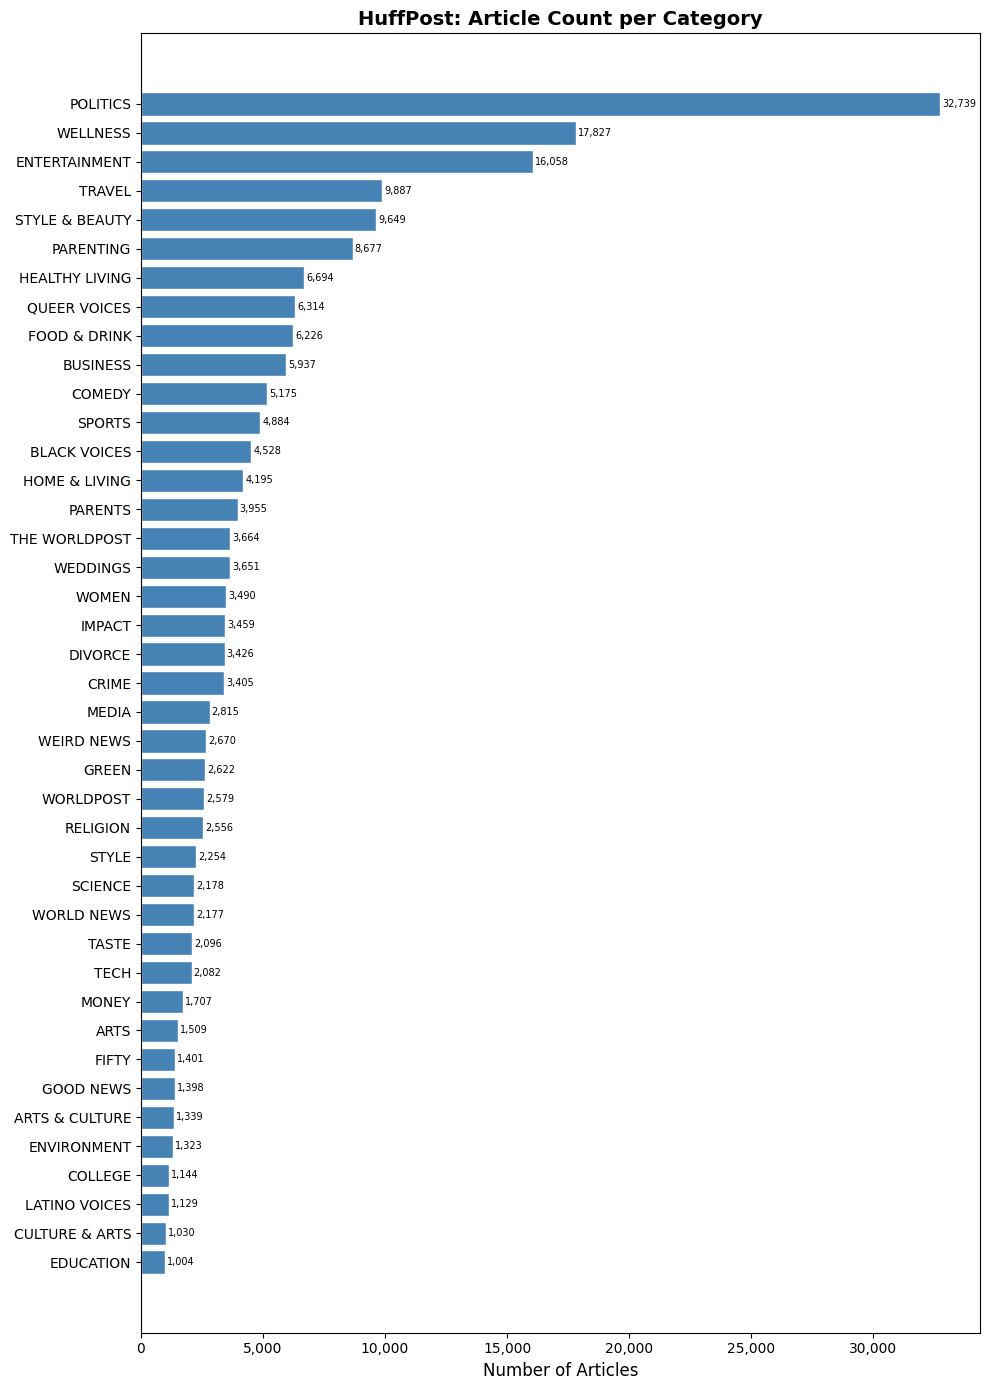

Saved: class_distribution.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 14))
cat_sorted = cat_counts.sort_values(ascending=True)   # largest bar at top
bars = ax.barh(cat_sorted.index, cat_sorted.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_title("HuffPost: Article Count per Category", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars, cat_sorted.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: class_distribution.png")

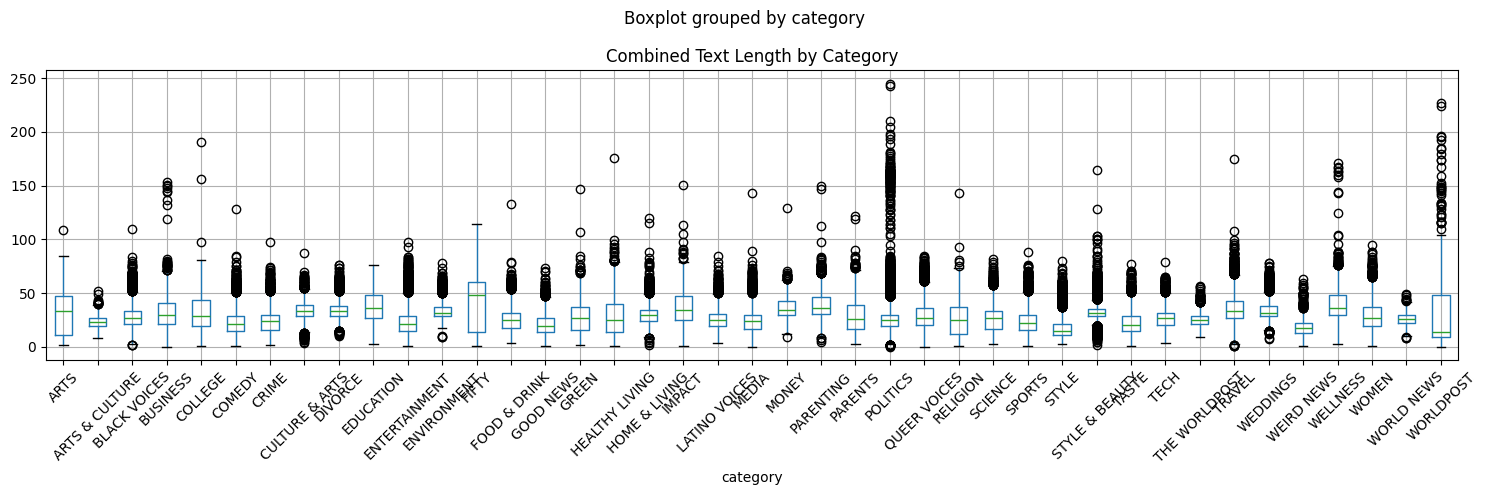

In [93]:
df.boxplot(column='n_words_total', by='category', figsize=(15, 5), rot=45)
plt.title('Combined Text Length by Category')
plt.tight_layout()
plt.show()

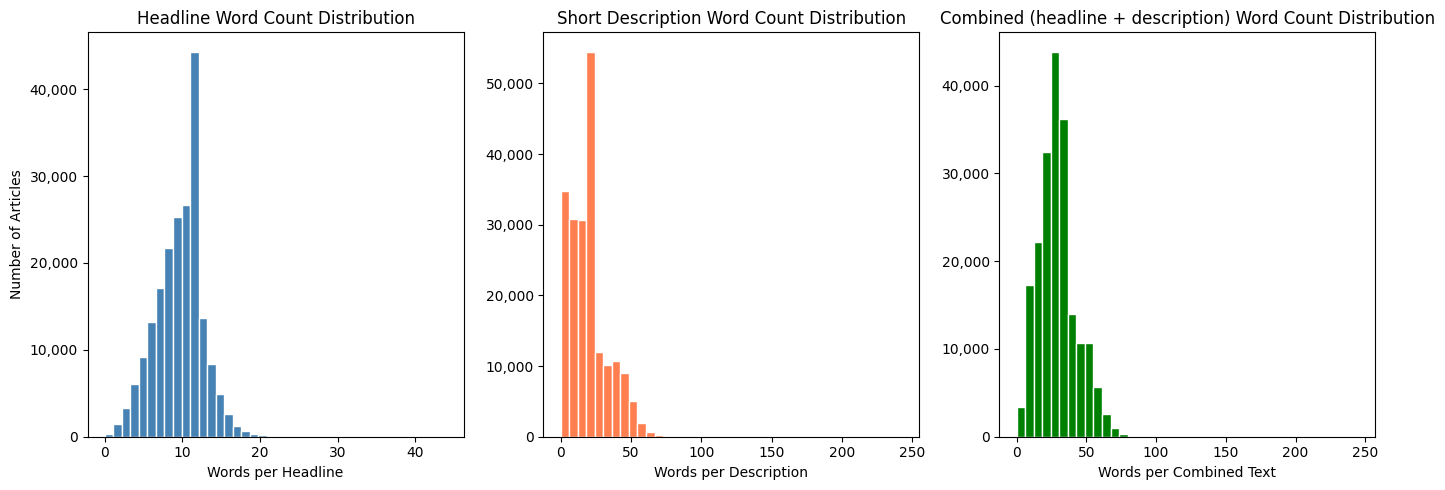

Saved: word_count_distribution.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].hist(df["n_words_headline"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Headline Word Count Distribution")
axes[0].set_xlabel("Words per Headline")
axes[0].set_ylabel("Number of Articles")

axes[1].hist(df["n_words_desc"], bins=40, color="coral", edgecolor="white")
axes[1].set_title("Short Description Word Count Distribution")
axes[1].set_xlabel("Words per Description")

axes[2].hist(df["n_words_total"], bins=40, color="green", edgecolor="white")
axes[2].set_title("Combined (headline + description) Word Count Distribution")
axes[2].set_xlabel("Words per Combined Text")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("word_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: word_count_distribution.png")

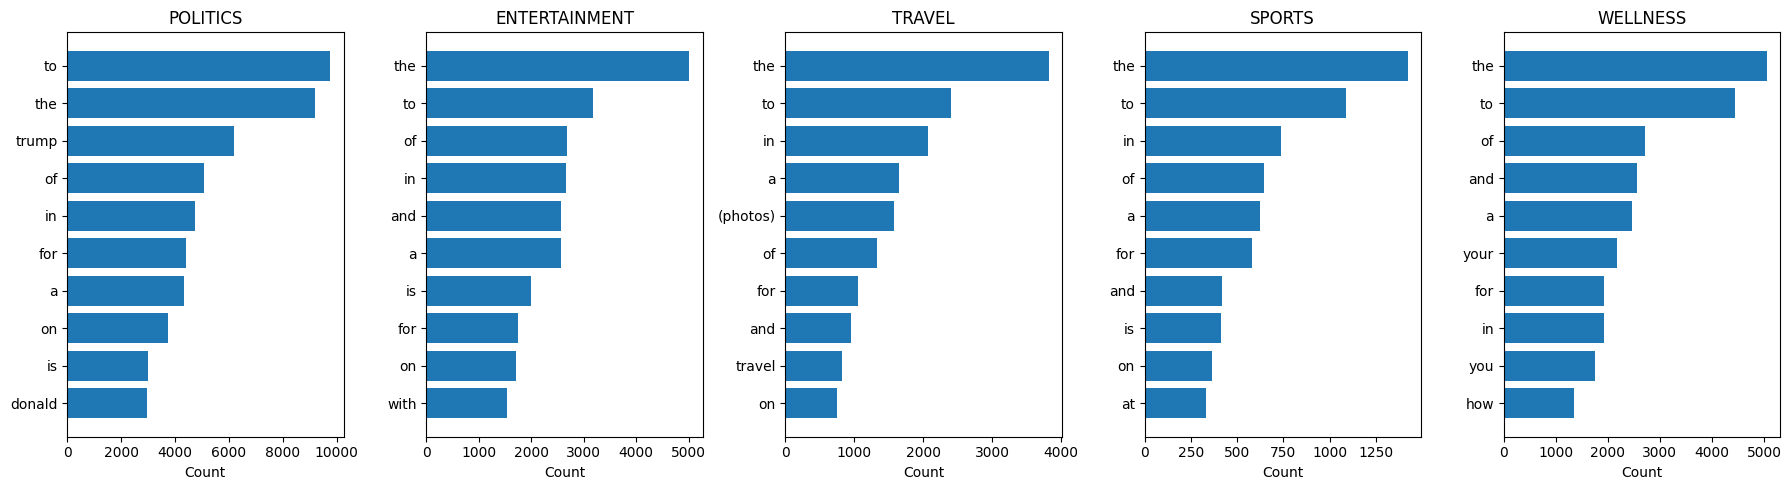

In [56]:
categories = ["POLITICS", "ENTERTAINMENT", "TRAVEL", "SPORTS", "WELLNESS"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, cat in zip(axes, categories):
    text = df[df["category"] == cat]["headline"].fillna("").str.cat(sep=" ")
    words = text.lower().split()
    common_words = Counter(words).most_common(10)
    labels, counts = zip(*common_words)

    ax.barh(labels[::-1], counts[::-1])
    ax.set_title(cat)
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Your answer here:**

The dataset is called HuffPost news dataset which is textual and is made up of news headlines and short article metadata like the news article headline, the date when the article was published, the author of the article, the category that the article falls under. HuffPost is an online news aggregator and the dataset has articles dating between 2012 and 2018. There are around 200k articles or samples and 41 distinct news categories/classes. Each sample is a news headline paired with a catgoery label such as Politics, Entertainment, Travel etc. The task I'll be working on is performing multi-class text classification where my essential goal is to train a model to automatically detect the relevant categories and tag them.

The business implication of this dataset can be useful for managing news websites / blogs or content platforms that manage vast amount of data every day. To better categorize the content, the business can train a machine learning model to automatically label each incoming article and deploy that model in production so the inference can happen in near real-time. The generated labels can also be used to tailor recommendation systems to accommodate user behavious/preferances. 

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Your answer here:**

Several things stood out from our EDA. First, the dataset is significantly class imbalanced. POLITICS dominates with 32,739 articles (16.3% of the data) while minority classes like EDUCATION, CULTURE & ARTS, and FIFTY have fewer than 1,000 articles each, giving an imbalance ratio of roughly 32:1 between the largest and smallest classes.

We also found 19,712 empty short descriptions (~9.8% of the dataset) and 6 empty headlines, which represent rows with little to no usable text signal. There were only 13 exact duplicates, which is negligible at this scale.
In terms of text length, headlines average ~9.5 words and descriptions ~20 words, both right-skewed with some outliers — one description reaching 243 words.

Finally, we noticed potential topic overlap between semantically similar categories like WORLDPOST and THE WORLDPOST, and PARENTS and PARENTING, which could introduce label ambiguity that even a human might struggle to distinguish.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Your answer here:**

Challenges that might affect model performance:

1. **Class Imabalance**: Since some categories have many samples than the others, the model may find it harder to predict the categories with very less samples.

2. **Ambiguous Labels**: Some categories are very similar to each other like mentioned before and this would make it hard for the model to adapt to the clear distinctions between the different variations of the realted categories. This would cause the model to misclassify the sample to near identical categories if not addressed. Some categories also feel like they should be merged into canonical categories to generalize better like COMEDY should be a part of ENTERTAINMENT category as it would make it hard to capture the slim nuances between such categories and may cause misclassfication.

3. **Sparse Text Limits**: Some samples have less context and make it harder for the model to predict any label or introduce hallucination and just randomly assign labels/categories that aren't relevant. Moreover, there are some category labels like Arts, WORLDPOST which have close to 50% empty short description rows.

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Your answer here:**

Preprocessing steps needed to Address issues:

1. Standardizing the category labels and creating a list of canonical categories to help the model generalize better and to address the confusion caused by ambiguous or overlapping labels/categories.

2. Remove redundant columns like date, author, links to only focus on relevant features.

3. Combining headline and description fields to address the issue of very short samples or address the missing short description rows.

4. Use class-weighting or oversampling techniques to address the class imbalance issue and better predict the under-represented categories too.

5. Normalize text using a transformer tokenizer to use a pretrained large language model to maximize our predictability.

6. Remove duplicate text to ensure that the train test split is perfect and to ensure there is no data leakage.

7. Train/val/test split — We would use a stratified 80/10/10 split with a fixed random seed to ensure class proportions are preserved across all three splits and results are reproducible.

5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Your answer here:**

We chose the HuffPost dataset over Food-101 for several reasons

1. computational accessibility — processing 200k short text strings is far less resource-intensive than handling 101k high-resolution images. Given our hardware constraints, a text-based dataset is a more practical choice for local development and experimentation.

2.   Real-world relevance — automatic content classification is a widely applicable NLP problem that mirrors tasks we are likely to encounter professionally, such as routing support tickets, tagging documents, or categorizing user-generated content. The skills we develop here transfer directly to industry use cases.

3. Third, interpretability — text data is inherently easier to inspect and reason about than image data. When our model makes a mistake, we can read the headline and description and understand why, which makes debugging and improving the model more intuitive.

We're hoping to learn how the state of the art transformers models can be utilized to solve real-world issues and also better understand the challenges dealing with text / language models.

## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



#### Category Counts

In [40]:
cat_counts = df["category"].value_counts()

for cat, cnt in cat_counts.items():
    pct = cnt / num_samples * 100
    print(f"  {cat:<30s} {cnt:>6,}  ({pct:5.1f}%)")

  POLITICS                       32,739  ( 16.3%)
  WELLNESS                       17,827  (  8.9%)
  ENTERTAINMENT                  16,058  (  8.0%)
  TRAVEL                          9,887  (  4.9%)
  STYLE & BEAUTY                  9,649  (  4.8%)
  PARENTING                       8,677  (  4.3%)
  HEALTHY LIVING                  6,694  (  3.3%)
  QUEER VOICES                    6,314  (  3.1%)
  FOOD & DRINK                    6,226  (  3.1%)
  BUSINESS                        5,937  (  3.0%)
  COMEDY                          5,175  (  2.6%)
  SPORTS                          4,884  (  2.4%)
  BLACK VOICES                    4,528  (  2.3%)
  HOME & LIVING                   4,195  (  2.1%)
  PARENTS                         3,955  (  2.0%)
  THE WORLDPOST                   3,664  (  1.8%)
  WEDDINGS                        3,651  (  1.8%)
  WOMEN                           3,490  (  1.7%)
  IMPACT                          3,459  (  1.7%)
  DIVORCE                         3,426  (  1.7%)


In [41]:
cat_counts.describe()

count       41.000000
mean      4898.853659
std       5793.753022
min       1004.000000
25%       2082.000000
50%       3405.000000
75%       5175.000000
max      32739.000000
Name: count, dtype: float64

In [38]:
cat_counts.max()/cat_counts.median()

9.614977973568282

In [44]:
for cat, cnt in cat_counts.items():
    pct = cnt / num_samples * 100
    if pct < 2:
        print(f"  {cat:<30s} {cnt:>6,}  ({pct:5.1f}%)")

  PARENTS                         3,955  (  2.0%)
  THE WORLDPOST                   3,664  (  1.8%)
  WEDDINGS                        3,651  (  1.8%)
  WOMEN                           3,490  (  1.7%)
  IMPACT                          3,459  (  1.7%)
  DIVORCE                         3,426  (  1.7%)
  CRIME                           3,405  (  1.7%)
  MEDIA                           2,815  (  1.4%)
  WEIRD NEWS                      2,670  (  1.3%)
  GREEN                           2,622  (  1.3%)
  WORLDPOST                       2,579  (  1.3%)
  RELIGION                        2,556  (  1.3%)
  STYLE                           2,254  (  1.1%)
  SCIENCE                         2,178  (  1.1%)
  WORLD NEWS                      2,177  (  1.1%)
  TASTE                           2,096  (  1.0%)
  TECH                            2,082  (  1.0%)
  MONEY                           1,707  (  0.8%)
  ARTS                            1,509  (  0.8%)
  FIFTY                           1,401  (  0.7%)


In [47]:
df['text_len'] = df['text'].str.split().str.len()

print(df['text_len'].quantile([0.50, 0.75, 0.90, 0.95]))

for max_len in [64, 128, 256]:
    truncated = (df['text_len'] > max_len).sum()
    print(f"max_length={max_len}: {truncated/len(df)*100:.1f}% truncated")

0.50    29.0
0.75    36.0
0.90    50.0
0.95    57.0
Name: text_len, dtype: float64
max_length=64: 1.6% truncated
max_length=128: 0.1% truncated
max_length=256: 0.0% truncated


In [52]:
print(f" Combined text duplicates: {n_dup_text:,}")
print(f" Duplicates in headline: {n_dup_head:,}")
print(f" Duplicates in short description: {n_dup_desc:,}")

 Combined text duplicates: 488
 Duplicates in headline: 1,509
 Duplicates in short description: 22,500


In [55]:
ambiguous_groups

[['WORLDPOST', 'THE WORLDPOST', 'WORLD NEWS'],
 ['ARTS & CULTURE', 'ARTS', 'CULTURE & ARTS'],
 ['STYLE', 'STYLE & BEAUTY'],
 ['HEALTHY LIVING', 'WELLNESS'],
 ['PARENTING', 'PARENTS'],
 ['COLLEGE', 'EDUCATION'],
 ['GREEN', 'ENVIRONMENT'],
 ['TASTE', 'FOOD & DRINK']]

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**

Given a HuffPost news article's headline and short description concatenated as "headline [SEP] short_description", our model will predict which of 41 topical categories the article belongs to. For example, "Given a news headline and summary, predict its topical category."
The label is the category field, representing the editorial section of HuffPost the article was published under, such as POLITICS, ENTERTAINMENT, or WELLNESS.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**

**Inputs**: The model receives a tokenized text string combining the article's headline and short description in the format "headline [SEP] short_description". The [SEP] token marks the boundary between the two fields, mirroring conventions used in transformer models like BERT. Each input is a variable-length sequence of tokens representing the content of the article.

**Outputs**: The model outputs a single categorical label from one of 41 possible HuffPost topic categories. For example, POLITICS, ENTERTAINMENT, or WELLNESS. Therefore, this is a single-label multi-class classification problem, meaning each article is assigned exactly one category.

3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**

1. **Class Imabalance:** As already stated in the initial analysis, further analysis also confirms that the dataset is heavily skewed. The class imabalance ratio is almost close to 10. The top class which is POLITICS itself account for 16% of the whole sample, while there are multiple small categories like EDUCATION, CULTURE & ARTS, COLLEGE, ENVIRONMENT, etc constitute for less than 2% of the dataset. As mentioned earlier, this is going to introduce bias to the model and over-predict the dominant classes and under-predict the small categories.

2. **Ambigous/Overlapping Labels:** There are several categories which are semantically similar which makes them ambiguous. For example, WOLDSPOST vs THE WORLDPOST vs WORLD NEWS have similar coverage of the articles. Moreover, ARTS vs ARTS & CULTURE vs CULTURE & ARTS also seem to have the same topic split across three labels. STYLE vs STYLE & BEAUTY also seem to be overlapping labels. These ambigous / overlapping classes might make it hard for the model to learn any meaningful patterns and also to learn the distinctions between them.

3. **Duplicate / Missing Data:** There are around 22,500 duplicates in the short description field, 1509 in the headlines field, and 488 in the combined text field. Moreover, there are around 19k articles where the short description field is empty and 6 which have empty headlines. 

4. **Noisy Data:** As seen in the word freq plot, there are a lot of words that provide little to no context to the task at hand and must be dealt with. For instance, the top words across the 5 different categories explored in our earlier analysis are "the" & "to". These type of words introduces noise to our model and don't really contribute much to the classification task. 

5. **Computing Constraint**: Running models with millions/billions of parameters on local machines can be challenging. Since none of these are api models, training or finetuning a large language model is going to be challenging as these models require a lot of RAM, GPUs. The full BERT model has around 110 million parameters, which is why we will be using the DistilBERT model as it runs 60% faster and requires far less memory than the full bert. 


4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size). 

2.4. **Your answer here:**

1. **Class Balancing with class_weight:** We will be using class balancing using class_weight approach which will basically compute an inverse-frequence class weights and will be used as the class weighted loss. This will ensure that the model will be penalized more for misclassifying the minority classes and address our class imbalance issue. Apparently over-sampling might risk overfitting which is the reasons why we're choosing the class_weight approach.

2. **Creating Canonical Labels:** The ambigous/overlapping labels will be merged appropriately to address the redundant label issue. For example, WORLDPOST, THE WORLDPOST, and WORLD NEWS will be merged into a single canonical label like WORLD NEWS; ARTS, ARTS&CULTURE, and CULTURE & ARTS into just ARTS & CULTURE, etc. This step not only reduces the # of labels/classes but also helps the model to clearly distinct each class.

3. **Deduplication and Cleaning** The ~500 duplicate combined text rows should be dropped to ensure that there is no data leakage and confusion. The 6 empty headline rows can also be safely dropped, and the 19k articles with empty description fields will just use the headline field to classify the category. We will also drop columns/fields like link, date, and author which are not useful for this task.

4. **Stop Word Removal:** Stopwords like "the", "a", "an", "to", etc will be removed if we were to not use the transformers model. However, if we were to use a transformer model, we will not be removing the stop words as it would break the natural language structure which is important for the state of the art transformers model.

5. **Tokenization:** We will be using a tokenizer from the huggingface transformers library to convert the combined text field into tokens before training the model as neural networks can't really understand the raw text directly. An appropriate max token length will be set to help address the memory and compute issues as really long texts will take forever to process. \

6. **Stratified splitting** — We will also apply a stratified 80/10/10 train/val/test split with a fixed random seed to preserve class proportions across all splits and ensure reproducibility.

5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Your answer here:**

Our primary success metric is going to be the macro F1-score as accuracy might not be a good metric since the data has a class-imbalance issue. F1-score makes sure that it's calculated per label independently and averages them with equal weight. This would ensure that a minority class like EDUCATION contribute to the final score just as much as the dominant class like POLITICS. Accuracy alone is not appropriate for this task as a model which only outputs POLITICS for every article will still end up with a ~16.5% accuracy but it can still be used as a complementary metric.

To complement our F1-score, we'll also utilize metrics like Per-class precision & recall to understand if the model is performing as expected across all classes, Confusion matrix to evaluate whether the model is facing ambiguity between labels, and Accuracy to understand how many articles are correctly being classified as a whole.

Our goal is to achieve a macro-f1 score of atleast 0.75 across all classes without no class F1 falling below 0.5.


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

Utilized Claude as a resource to validate thinking and fill conceptual gaps during the following scenarios:

Validate our own observations — for example confirming whether merging certain label groups like WORLDPOST/THE WORLDPOST/WORLD NEWS was statistically and semantically justified

Clarifying concepts — such as the difference between macro-F1, weighted F1, and accuracy, and when each is appropriate

Reviewing and improving our written answers — providing drafts and asking for feedback on clarity and completeness

Debug and simplify code — particularly for the EDA sections involving word frequency plots and visualizations

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

